# Mip-Splatting: pipeline e comparacao com baselines

Estudo de ponta a ponta sobre um leao real capturado em video. Etapas:

1. Extrai os quadros mais nitidos do video e roda COLMAP.
2. Treina o modelo proposto pelo paper, o Mip-Splatting.
3. Treina os baselines 3DGS e 3DGS+EWA no mesmo COLMAP.
4. Compara os tres no protocolo do paper: treino numa escala (-r 2), teste em varias (-r 1,2,4,8).
5. Mostra frames estaticos dos tres modelos em diferentes niveis de zoom.

Os modelos diferem nos filtros:

| Modelo | Filtro 3D de suavizacao | Filtro 2D | Papel |
|--------|--------------------------|-----------|-------|
| Mip-Splatting | sim | Mip, low-pass com compensacao de opacidade | metodo proposto |
| 3DGS | nao | dilatacao fixa de 0.3px | baseline classico |
| 3DGS+EWA | nao | EWA, low-pass | baseline antialiasing |

Treino, held-out e metricas sao os mesmos para os tres.

## 1. Configuracao

In [2]:
%matplotlib inline
import os, sys, json, glob, shutil, subprocess
import numpy as np

ROOT = os.path.abspath(os.getcwd())

PY = "/home/dante/.conda/envs/mip-splatting/bin/python"
PY_GS = "/home/dante/miniconda3/envs/gs3dgs/bin/python"
GS_REPO = "baselines/gaussian-splatting"

COLMAP = "/home/dante/.conda/envs/mip-splatting/bin/colmap"
COLMAP_ENV = {"LD_LIBRARY_PATH": "/home/dante/.conda/envs/mip-splatting/lib:" + os.environ.get("LD_LIBRARY_PATH", "")}

VIDEO = "data/leao_video/IMG_3124.MOV"   # video bruto
SOURCE = "data/leao"                      # pasta de trabalho do COLMAP
N_FRAMES = 300   # quadros extraidos do video
RES = 2          # escala do treino (-r); o teste varre 1,2,4,8
ITER = 30000     # iteracoes de treino
SCALES = [1, 2, 4, 8]

MODELS = [
    {"nome": "Mip-Splatting", "dir": "output/leao",         "antialias": False},
    {"nome": "3DGS",          "dir": "output/leao_3dgs",     "antialias": False},
    {"nome": "3DGS+EWA",      "dir": "output/leao_3dgs_ewa", "antialias": True},
]

def run(cmd, cwd=None, extra_env=None):
    env = os.environ.copy()
    if extra_env:
        env.update(extra_env)
    print(">", " ".join(map(str, cmd)))
    if subprocess.run(cmd, cwd=cwd, env=env).returncode != 0:
        raise RuntimeError("comando falhou: " + " ".join(map(str, cmd)))

def treinado(model_dir):
    return os.path.exists(f"{model_dir}/point_cloud/iteration_{ITER}/point_cloud.ply")

print("PY    =", PY)
print("PY_GS =", PY_GS)
print("SOURCE=", SOURCE)

PY    = /home/dante/.conda/envs/mip-splatting/bin/python
PY_GS = /home/dante/miniconda3/envs/gs3dgs/bin/python
SOURCE= data/leao


In [ ]:
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def log_treino_anterior(model_dir, iters):
    """Quando o treino ja foi feito em sessao anterior, recupera do TensorBoard
    (tfevents, gravado pelo proprio train.py) o log real daquela execucao:
    duracao, it/s, loss e PSNR de teste/val. Nao reexecuta nada."""
    evs = sorted(glob.glob(os.path.join(model_dir, "events.out.tfevents.*")))
    ea, ev_path = None, None
    for ev in evs:
        cand = EventAccumulator(ev, size_guidance={"scalars": 0})
        cand.Reload()
        tags = cand.Tags().get("scalars", [])
        if "train_loss_patches/total_loss" in tags:
            loss = cand.Scalars("train_loss_patches/total_loss")
            if len(loss) >= iters:
                ea, ev_path = cand, ev
                break
    if ea is None:
        print(f"  (nenhum tfevents completo em {model_dir})")
        return

    loss = ea.Scalars("train_loss_patches/total_loss")
    it_time = ea.Scalars("iter_time")
    dur_min = (loss[-1].wall_time - loss[0].wall_time) / 60
    avg_its = len(it_time) / (it_time[-1].wall_time - it_time[0].wall_time)
    print(f"  {model_dir}: {len(loss)} it, "
          f"{dur_min:.1f} min, {avg_its:.2f} it/s medio, loss final={loss[-1].value:.4f}")
    for tag in ea.Tags()["scalars"]:
        if "psnr" in tag:
            pts = ea.Scalars(tag)
            print("   " + tag + ": " + ", ".join(f"it{p.step}={p.value:.2f}dB" for p in pts))

    steps = [s.step for s in loss]
    vals = [s.value for s in loss]
    plt.figure(figsize=(6, 2.6))
    plt.plot(steps, vals, lw=0.4, alpha=0.8)
    plt.xlabel("iteracao"); plt.ylabel("total_loss")
    plt.title(model_dir)
    plt.tight_layout(); plt.show()

## 2. Dados

Extrai `N_FRAMES` quadros do video pegando o mais nitido de cada janela temporal (variancia do
Laplaciano), o que reduz borrao de movimento e ajuda o casamento de features. Depois roda o COLMAP
via `convert.py`. As duas etapas pulam se o artefato ja existe.

In [2]:
import cv2

def extrair_frames(video, destino, n_frames):
    os.makedirs(destino, exist_ok=True)
    cap = cv2.VideoCapture(video)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    bordas = np.linspace(0, total, n_frames + 1).astype(int)
    nitidez = lambda cinza: cv2.Laplacian(cinza, cv2.CV_64F).var()
    salvos = 0
    for j in range(n_frames):
        ini, fim = bordas[j], bordas[j + 1]
        if fim <= ini:
            continue
        melhor, melhor_score = None, -1.0
        for idx in np.linspace(ini, fim - 1, min(6, fim - ini)).astype(int):
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
            ok, quadro = cap.read()
            if not ok:
                continue
            score = nitidez(cv2.cvtColor(quadro, cv2.COLOR_BGR2GRAY))
            if score > melhor_score:
                melhor_score, melhor = score, quadro
        if melhor is not None:
            cv2.imwrite(os.path.join(destino, "leao_%03d.jpg" % salvos), melhor, [cv2.IMWRITE_JPEG_QUALITY, 95])
            salvos += 1
    cap.release()
    return salvos

entrada = os.path.join(SOURCE, "input")
if len(glob.glob(os.path.join(entrada, "*.jpg"))) >= N_FRAMES:
    print("Quadros ja extraidos em", entrada)
else:
    print("Quadros extraidos:", extrair_frames(VIDEO, entrada, N_FRAMES))

if os.path.exists(os.path.join(SOURCE, "sparse", "0", "points3D.bin")):
    print("COLMAP ja processado em", SOURCE)
else:
    run([PY, "convert.py", "-s", SOURCE, "--colmap_executable", COLMAP], extra_env=COLMAP_ENV)

run([COLMAP, "model_analyzer", "--path", os.path.join(SOURCE, "sparse", "0")], extra_env=COLMAP_ENV)

Quadros ja extraidos em data/leao/input
COLMAP ja processado em data/leao
> /home/dante/.conda/envs/mip-splatting/bin/colmap model_analyzer --path data/leao/sparse/0


I20260627 19:19:16.597344 139737036582912 model.cc:446] Cameras: 1
I20260627 19:19:16.597401 139737036582912 model.cc:447] Images: 300
I20260627 19:19:16.597403 139737036582912 model.cc:448] Registered images: 300
I20260627 19:19:16.597406 139737036582912 model.cc:450] Points: 169552
I20260627 19:19:16.597407 139737036582912 model.cc:451] Observations: 1113727
I20260627 19:19:16.597421 139737036582912 model.cc:453] Mean track length: 6.568646
I20260627 19:19:16.597429 139737036582912 model.cc:455] Mean observations per image: 3712.423333
I20260627 19:19:16.597432 139737036582912 model.cc:458] Mean reprojection error: 0.614051px


## 3. Mip-Splatting

Treina o modelo proposto: filtro 3D de suavizacao ligado e filtro 2D Mip, os dois defaults do repositorio do artigo. Hold-out a cada 8 imagens para treino em escala r2

Mip-Splatting ja treinado em output/leao
  output/leao: 30000 it, 30.9 min, 16.20 it/s medio, loss final=0.0427
   test/loss_viewpoint - psnr: it7000=21.50dB
   val/loss_viewpoint - psnr: it7000=21.32dB
   train/loss_viewpoint - psnr: it7000=23.23dB


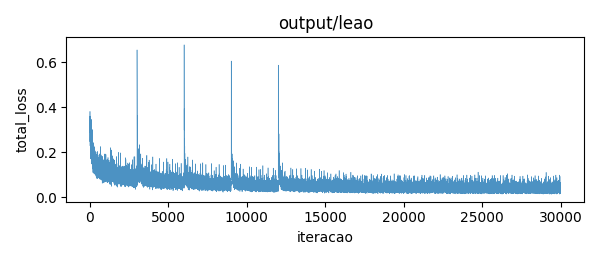

In [4]:
mip = MODELS[0]["dir"]
if treinado(mip):
    print("Mip-Splatting ja treinado em", mip)
    log_treino_anterior(mip, ITER)
else:
    run([PY, "train.py", "-s", SOURCE, "-m", mip, "--eval", "-r", str(RES),
         "--kernel_size", "0.1", "--test_iterations", "7000", "--save_iterations", str(ITER), "--quiet"])

## 4. Baselines: 3DGS e 3DGS+EWA

Treinados pelo repo oficial do 3DGS no MESMO COLMAP e MESMO held-out, com os mesmos hiperparametros
do Mip. O 3DGS+EWA e o 3DGS com argumento --antialiasing.

### Setup do env dos baselines

ja treinado: output/leao_3dgs
  output/leao_3dgs: 30000 it, 22.3 min, 22.44 it/s medio, loss final=0.0295
   test/loss_viewpoint - psnr: it7000=20.98dB, it30000=22.17dB
   train/loss_viewpoint - psnr: it7000=23.75dB, it30000=27.28dB


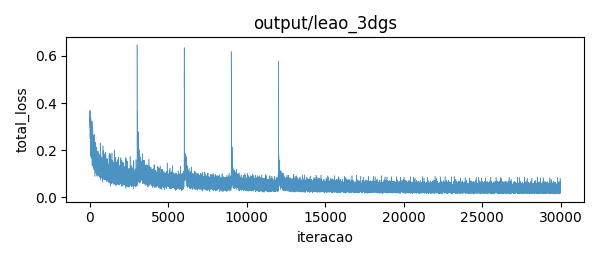

ja treinado: output/leao_3dgs_ewa
  output/leao_3dgs_ewa: 30000 it, 23.6 min, 21.18 it/s medio, loss final=0.0316
   test/loss_viewpoint - psnr: it7000=21.32dB, it30000=22.55dB
   train/loss_viewpoint - psnr: it7000=23.68dB, it30000=26.98dB


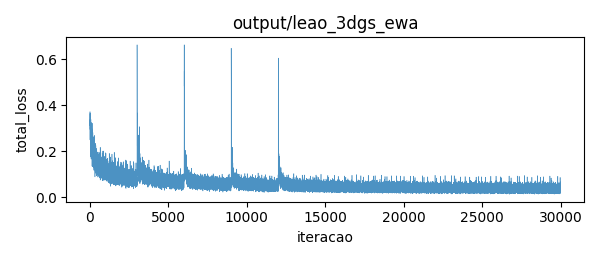

In [5]:
def treinar_baseline(model_dir, antialias):
    if treinado(model_dir):
        print("ja treinado:", model_dir)
        log_treino_anterior(model_dir, ITER)
        return
    cmd = [PY_GS, "train.py", "-s", os.path.abspath(SOURCE), "-m", os.path.abspath(model_dir),
           "--eval", "-r", str(RES), "--save_iterations", str(ITER), "--test_iterations", "7000",
           "--disable_viewer", "--quiet"]
    if antialias:
        cmd.append("--antialiasing")
    run(cmd, cwd=GS_REPO)

if not os.path.exists(PY_GS):
    print("Env gs3dgs ausente. Rode o setup acima antes de treinar os baselines.")
else:
    for m in MODELS[1:]:
        treinar_baseline(m["dir"], m["antialias"])

## 5. Avaliacao multi-escala

O experimento do paper: treina em -r 2, testa em -r 1, 2, 4, 8. -r 1 e zoom-in (resolucao
acima do treino) e -r 4, 8 sao zoom-out (abaixo). 

Os filtros so aparecem quando a escala muda:
| filtro | protege contra | regime que o estressa |
|--------|----------------|------------------------|
| 2D, Mip ou EWA | aliasing ao reduzir a resolucao | zoom-out (-r alto) |
| 3D de suavizacao | dilatacao e agulhas ao aumentar a resolucao | zoom-in (-r baixo) |

In [5]:
def tem_render(model_dir, scale):
    d = f"{model_dir}/test/ours_{ITER}/test_preds_{scale}"
    return os.path.isdir(d) and len(glob.glob(d + "/*.png")) > 0

def render_mip(model_dir, scale):
    run([PY, "render.py", "-m", model_dir, "--skip_train", "-r", str(scale), "--quiet"])

def render_baseline(model_dir, scale, antialias):
    cmd = [PY_GS, "render.py", "-m", os.path.abspath(model_dir), "--skip_train", "-r", str(scale), "--quiet"]
    if antialias:
        cmd.append("--antialiasing")
    run(cmd, cwd=GS_REPO)
    base = f"{model_dir}/test/ours_{ITER}"
    for src, dst in (("renders", f"test_preds_{scale}"), ("gt", f"gt_{scale}")):
        if os.path.isdir(f"{base}/{dst}"):
            shutil.rmtree(f"{base}/{dst}")
        os.rename(f"{base}/{src}", f"{base}/{dst}")

for scale in SCALES:
    for i, m in enumerate(MODELS):
        if tem_render(m["dir"], scale):
            continue
        if i == 0:
            render_mip(m["dir"], scale)
        else:
            render_baseline(m["dir"], scale, m["antialias"])
print("renders multi-escala prontos")

renders multi-escala prontos


Metricas com a MESMA implementacao para os tres (PSNR, SSIM e LPIPS-VGG). O held-out do Mip
(test+val) e combinado por media ponderada.

In [6]:
import torch
import torchvision.transforms.functional as tf
import pandas as pd
from PIL import Image
from IPython.display import display
from utils.loss_utils import ssim
from utils.image_utils import psnr

AGG = "output/leao_paper_compare.json"

def medir(renders_dir, gt_dir, lpips_fn):
    nomes = sorted(os.listdir(renders_dir))
    acc = {"PSNR": 0.0, "SSIM": 0.0, "LPIPS": 0.0}
    for n in nomes:
        r = tf.to_tensor(Image.open(f"{renders_dir}/{n}")).unsqueeze(0)[:, :3].cuda()
        g = tf.to_tensor(Image.open(f"{gt_dir}/{n}")).unsqueeze(0)[:, :3].cuda()
        acc["PSNR"] += psnr(r, g).item()
        acc["SSIM"] += ssim(r, g).item()
        acc["LPIPS"] += lpips_fn(r, g).item()
    n = len(nomes)
    return n, {k: v / n for k, v in acc.items()}

def metricas_modelo(model_dir, is_mip, scale, lpips_fn):
    nt, t = medir(f"{model_dir}/test/ours_{ITER}/test_preds_{scale}", f"{model_dir}/test/ours_{ITER}/gt_{scale}", lpips_fn)
    if not is_mip:
        return t
    nv, v = medir(f"{model_dir}/val/ours_{ITER}/test_preds_{scale}", f"{model_dir}/val/ours_{ITER}/gt_{scale}", lpips_fn)
    return {k: (nt * t[k] + nv * v[k]) / (nt + nv) for k in t}

if os.path.exists(AGG):
    cmp = json.load(open(AGG))
else:
    import lpips
    lpips_fn = lpips.LPIPS(net="vgg").cuda()
    data = {m["nome"]: {str(s): metricas_modelo(m["dir"], i == 0, s, lpips_fn) for s in SCALES}
            for i, m in enumerate(MODELS)}
    cmp = {"train_res": RES, "scales": SCALES, "models": [m["nome"] for m in MODELS], "data": data}
    json.dump(cmp, open(AGG, "w"), indent=2)

def tabela(metric):
    linhas = {m: [cmp["data"][m][str(s)][metric] for s in SCALES] for m in cmp["models"]}
    return pd.DataFrame(linhas, index=["-r %d" % s for s in SCALES]).T.round(2 if metric == "PSNR" else 4)

for metric in ("PSNR", "SSIM", "LPIPS"):
    melhor = "menor=melhor" if metric == "LPIPS" else "maior=melhor"
    print("%s por escala (%s; treino=-r%d, -r1=zoom-in, -r8=zoom-out)" % (metric, melhor, cmp["train_res"]))
    display(tabela(metric))

PSNR por escala (maior=melhor; treino=-r2, -r1=zoom-in, -r8=zoom-out)


,-r 1,-r 2,-r 4,-r 8
Mip-Splatting,22.16,22.50,22.89,22.91
3DGS,21.12,22.08,21.20,19.19
3DGS+EWA,21.86,22.44,22.71,22.43


SSIM por escala (maior=melhor; treino=-r2, -r1=zoom-in, -r8=zoom-out)


,-r 1,-r 2,-r 4,-r 8
Mip-Splatting,0.8769,0.8885,0.8980,0.8971
3DGS,0.8540,0.8812,0.8523,0.7605
3DGS+EWA,0.8644,0.8855,0.8897,0.8801


LPIPS por escala (menor=melhor; treino=-r2, -r1=zoom-in, -r8=zoom-out)


,-r 1,-r 2,-r 4,-r 8
Mip-Splatting,0.1970,0.1441,0.1040,0.0895
3DGS,0.2240,0.1555,0.1419,0.1650
3DGS+EWA,0.2192,0.1550,0.1213,0.1125


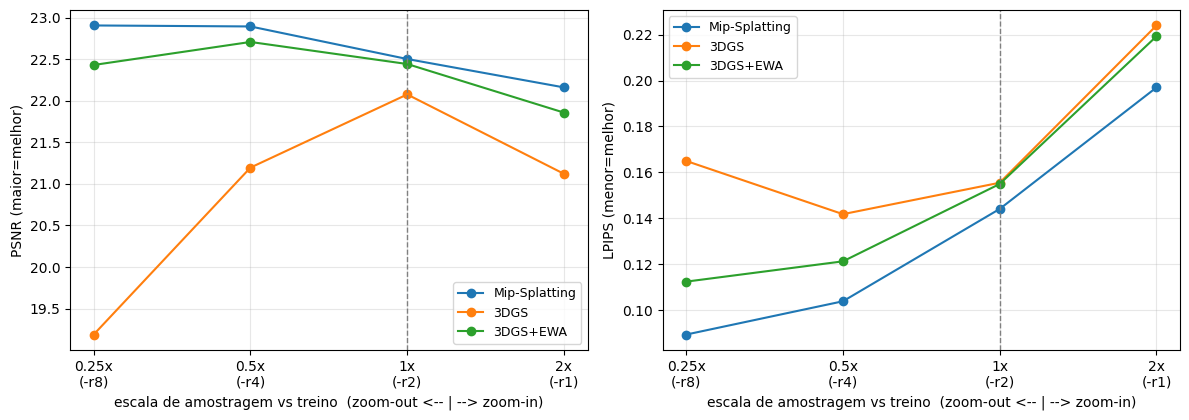

In [7]:
import matplotlib.pyplot as plt

xs = sorted((RES / s, s) for s in SCALES)
escala, sc = [x for x, _ in xs], [s for _, s in xs]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for ax, (metric, melhor) in zip(axes, (("PSNR", "maior=melhor"), ("LPIPS", "menor=melhor"))):
    for m in cmp["models"]:
        ax.plot(escala, [cmp["data"][m][str(s)][metric] for s in sc], marker="o", label=m)
    ax.axvline(1.0, ls="--", color="gray", lw=1)
    ax.set_xscale("log", base=2)
    ax.set_xticks(escala)
    ax.set_xticklabels(["%gx\n(-r%d)" % (x, s) for x, s in zip(escala, sc)])
    ax.set_xlabel("escala de amostragem vs treino  (zoom-out <-- | --> zoom-in)")
    ax.set_ylabel("%s (%s)" % (metric, melhor))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Visualizacao: frames estaticos de zoom

As metricas de um unico `-r` escondem o efeito dos filtros; a prova qualitativa esta na navegacao
multi-escala. Os tres usam a mesma camera de referencia (mesmo COLMAP, mesmo held-out), entao os frames ficam alinhados.

guardado em output/comparacao_crop_zoom.png


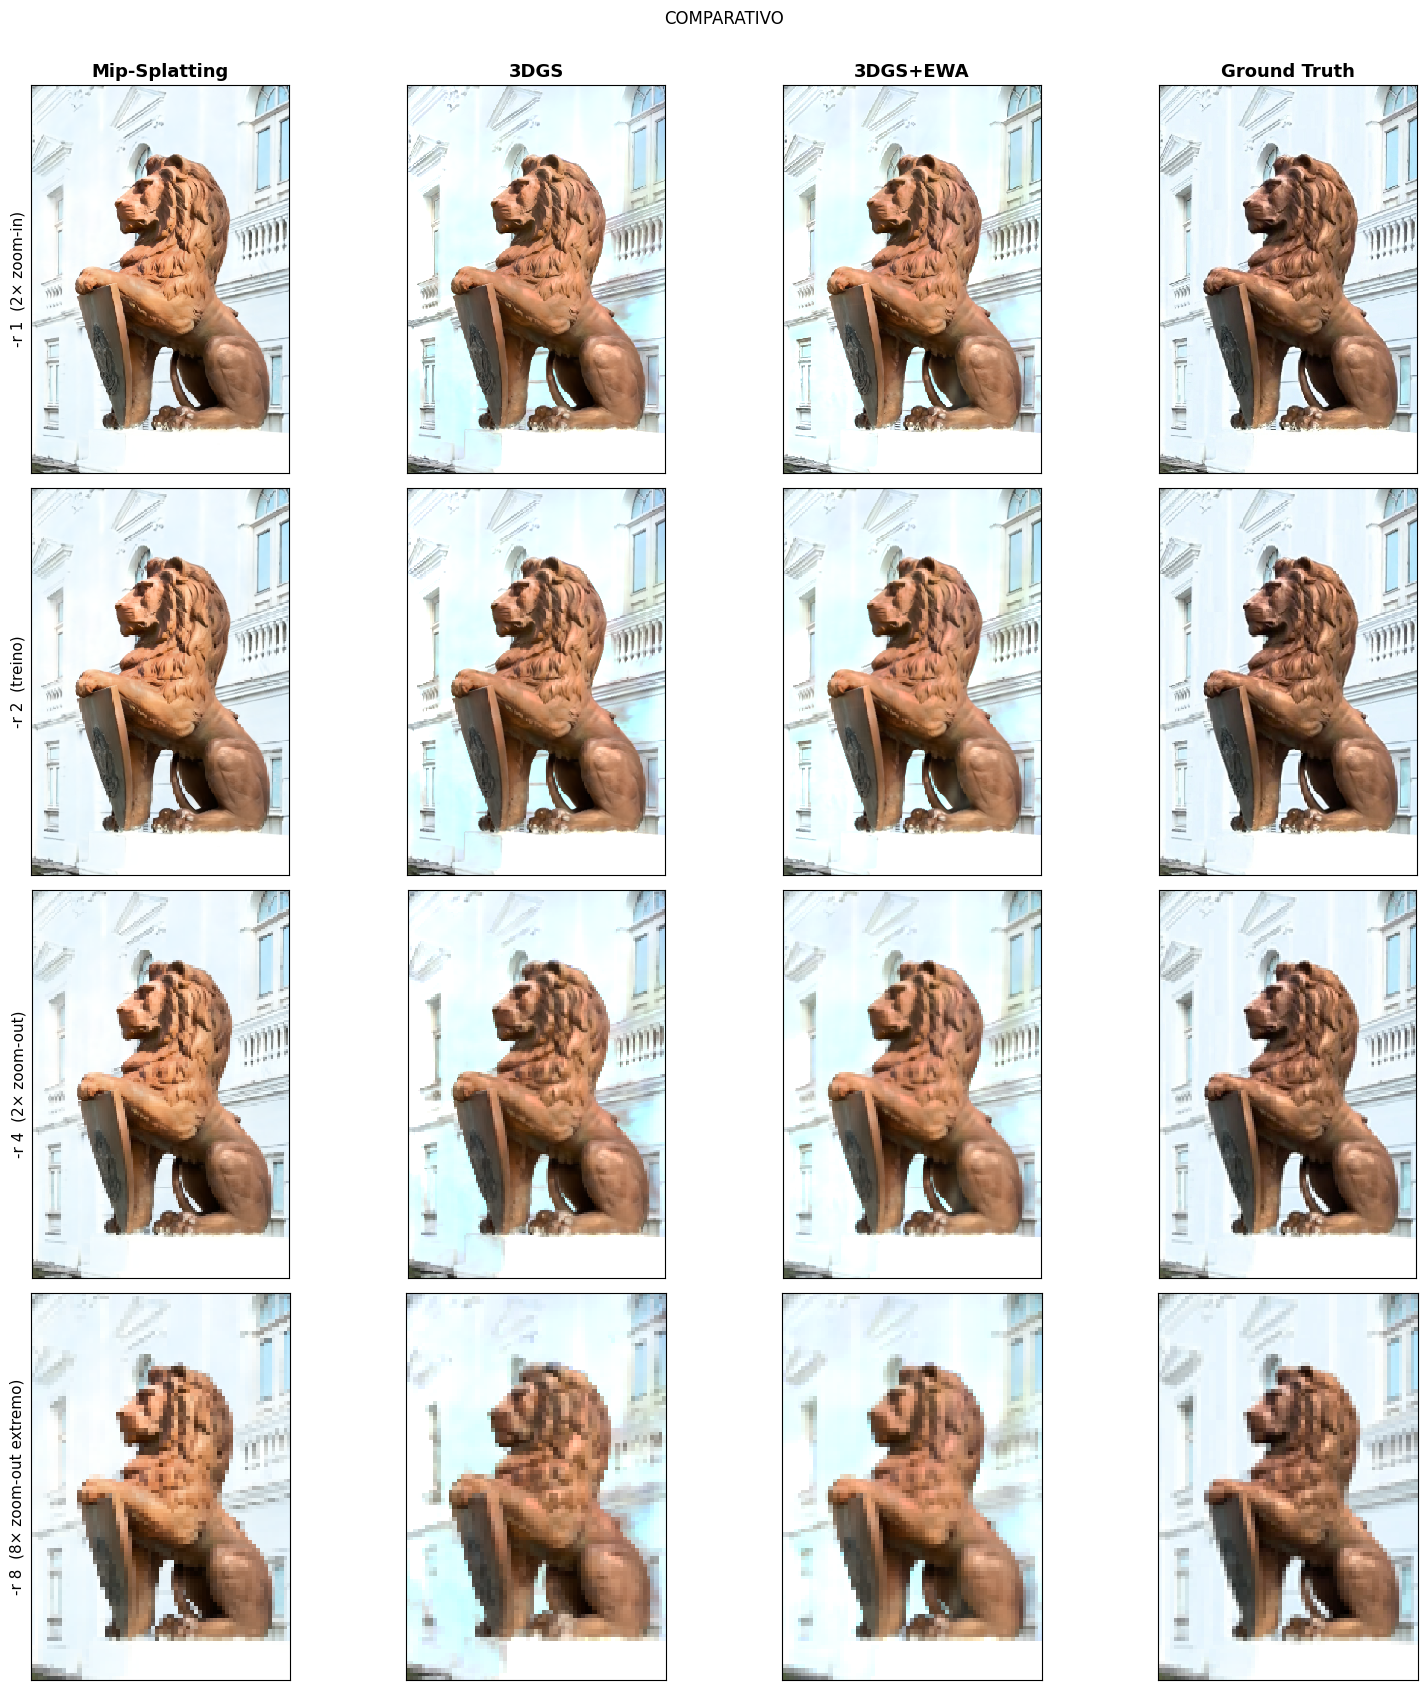

In [9]:
from PIL import Image
import matplotlib.pyplot as plt, numpy as np, os

MIP_FRAME  = 17        
GS_FRAME   = MIP_FRAME * 2   

SHOW_SCALES = [1, 2, 4, 8]
SHOW_LABS   = ["-r 1  (2× zoom-in)", "-r 2  (treino)", "-r 4  (2× zoom-out)", "-r 8  (8× zoom-out extremo)"]

CROP = (0.45, 0.13, 0.95, 0.55)

DISPLAY_H  = 520  

COL_DEFS = [
    {"nome": "Mip-Splatting", "gt": False, "dir": MODELS[0]["dir"],  "frame": MIP_FRAME},
    {"nome": "3DGS",          "gt": False, "dir": MODELS[1]["dir"],  "frame": GS_FRAME},
    {"nome": "3DGS+EWA",      "gt": False, "dir": MODELS[2]["dir"],  "frame": GS_FRAME},
    {"nome": "Ground Truth",  "gt": True,  "dir": MODELS[0]["dir"],  "frame": MIP_FRAME},
]

def load_crop(col, scale, crop_frac, display_h):
    subdir = "gt" if col["gt"] else "test_preds"
    path   = f"{col['dir']}/test/ours_{ITER}/{subdir}_{scale}/{col['frame']:05d}.png"
    img = Image.open(path).convert("RGB")
    w, h = img.size
    l, t, r, b = int(w*crop_frac[0]), int(h*crop_frac[1]), int(w*crop_frac[2]), int(h*crop_frac[3])
    patch = img.crop((l, t, r, b))
    pw, ph = patch.size
    new_w = int(pw * display_h / ph)
    return np.array(patch.resize((new_w, display_h), Image.NEAREST))

fig, axes = plt.subplots(len(SHOW_SCALES), len(COL_DEFS),
                          figsize=(4.0 * len(COL_DEFS), 4.2 * len(SHOW_SCALES)))

for r, (scale, lab) in enumerate(zip(SHOW_SCALES, SHOW_LABS)):
    for c, col in enumerate(COL_DEFS):
        arr = load_crop(col, scale, CROP, DISPLAY_H)
        axes[r, c].imshow(arr, interpolation="nearest")
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if r == 0:
            axes[r, c].set_title(col["nome"], fontsize=13, fontweight="bold")
        if c == 0:
            axes[r, c].set_ylabel(lab, fontsize=11)

plt.suptitle("COMPARATIVO", y=1.003, fontsize=12)
plt.tight_layout()
out_path = "output/comparacao_crop_zoom.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print("guardado em", out_path)
plt.show()